In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore",, category=UserWarning)

In [11]:
df=pd.read_csv(r"C:\Users\ganna\Downloads\economic_index multi.csv")
df

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


In [12]:
df.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)
df

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [13]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

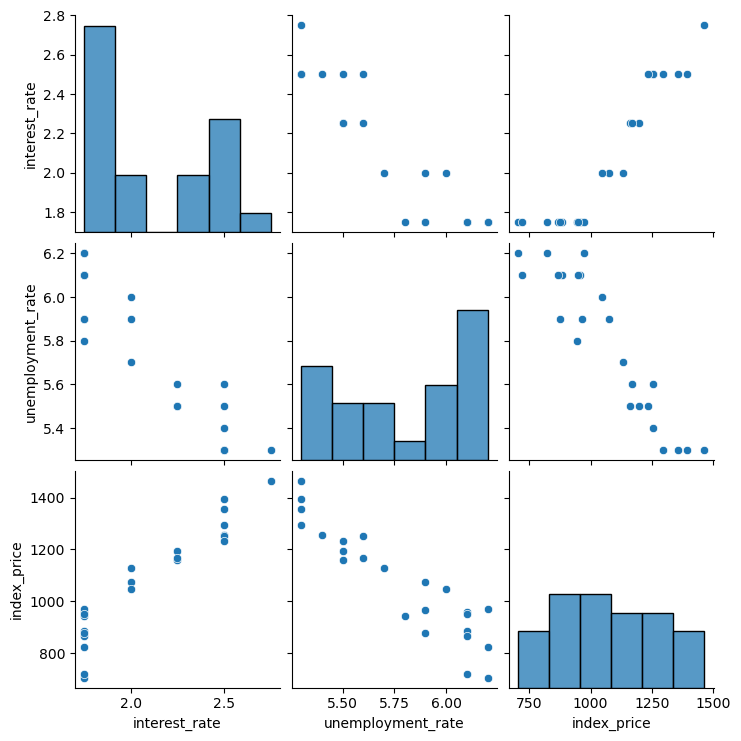

In [14]:
import seaborn as sns
sns.pairplot(df)
plt.show()

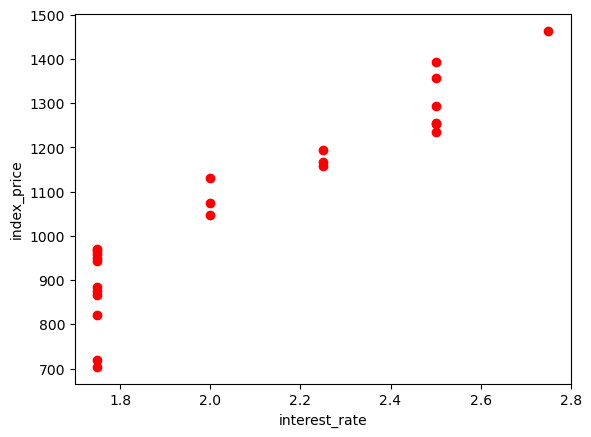

In [15]:
plt.scatter(df["interest_rate"],df["index_price"],color="r")
plt.xlabel("interest_rate")
plt.ylabel("index_price")
plt.show()

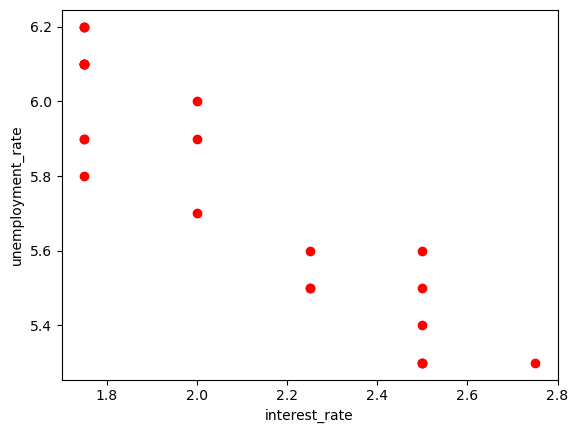

In [16]:
plt.scatter(df["interest_rate"],df["unemployment_rate"],color="r")
plt.xlabel("interest_rate")
plt.ylabel("unemployment_rate")
plt.show()

In [17]:
x=df.iloc[:,:-1]
x

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4
5,2.50,5.6
6,2.50,5.5
7,2.25,5.5
8,2.25,5.5
9,2.25,5.6


In [18]:
y=df.iloc[:,-1]
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

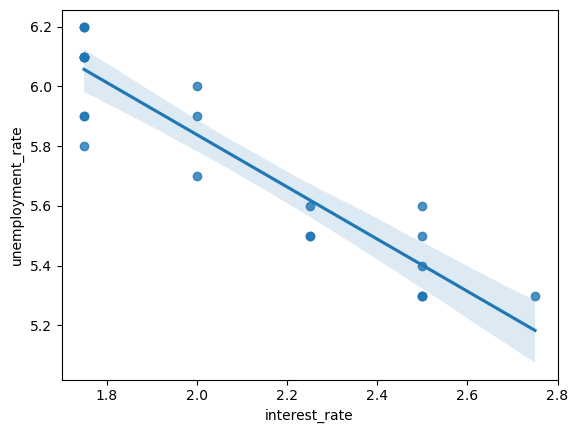

In [20]:
import seaborn as sns
sns.regplot(x="interest_rate",y="unemployment_rate",data=df)
plt.show()

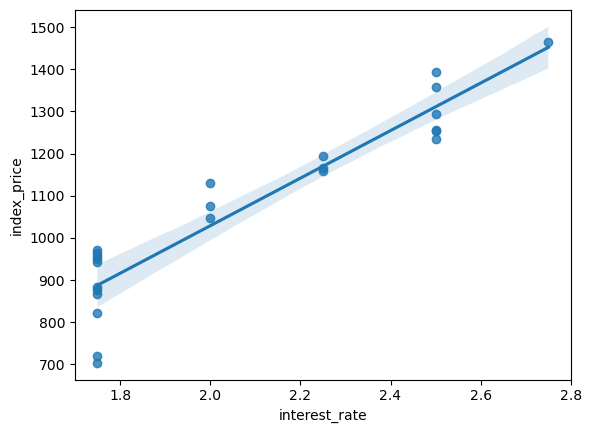

In [21]:
import seaborn as sns
sns.regplot(x="interest_rate",y="index_price",data=df)
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [23]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(x_train,y_train)

LinearRegression()

In [24]:
print(regression.coef_)
regression.intercept_

[  88.27275507 -116.25716066]


np.float64(1053.4444444444443)

In [25]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,x_train,y_train,scoring="neg_mean_squared_error",cv=3)
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [26]:
np.mean(validation_score)

np.float64(-5914.828180162388)

In [27]:
y_pre=regression.predict(x_test)

In [28]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,y_pre)
print("mse",mse)
mae=mean_absolute_error(y_test,y_pre)
print("mae",mae)
rmse=np.sqrt(mse)
print("rmse",rmse)
r2=r2_score(y_test,y_pre)
print("r2",r2)

mse 5793.762887712583
mae 59.93578152323558
rmse 76.11677139574815
r2 0.8278978091457141


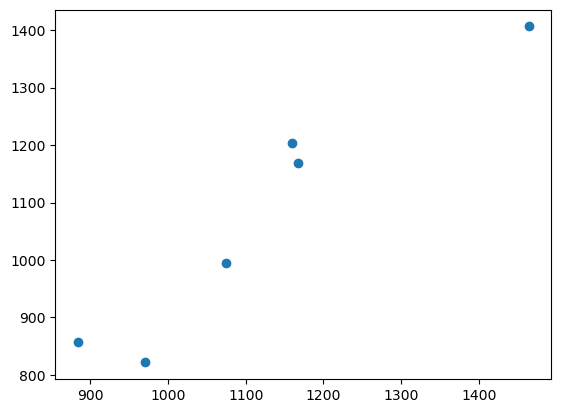

In [29]:
plt.scatter(y_test,y_pre)
plt.show()

In [30]:
residuals=y_test-y_pre
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


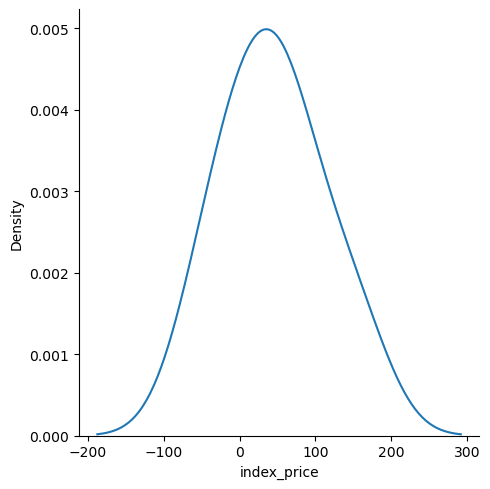

In [31]:
sns.displot(residuals,kind="kde")
plt.show()

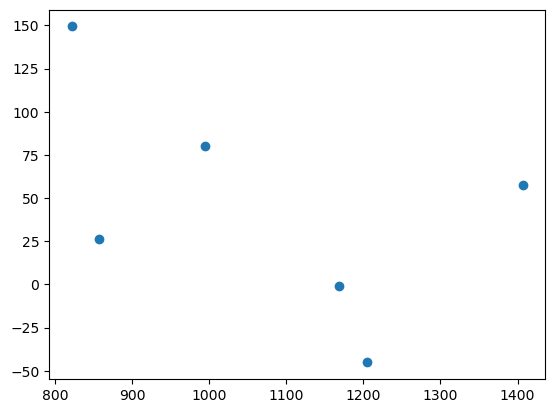

In [32]:
plt.scatter(y_pre,residuals)
plt.show()

In [33]:
regression.predict(sc.transform([[2.75,5.3]]))

C:\Users\ganna\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1406.51300368])

In [34]:
predi=(1464-1406.51300368)/1464
predi*100

3.926707398907096